 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submisison 
Name           : Steven McGuire  <br>
Student Number : L00196739         <br>
Due Date       : 12/05/2026           <br>
Assignment     : CA2             <br>
Module         : AI for Vision and NLP    <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## NLP and Vision Pipeline : High Level


This project builds a multi-modal document understanding pipeline for selected pages of the 2026 IPF Technical Rulebook. The system converts PDF pages to images, applies image preprocessing, extracts text using OCR, applies NLP preprocessing, detects document layout features, and produces structured textual and visual insights.

Although the module covers both NLP and computer vision, this workflow begins with image preprocessing because the source material is a PDF document. The extracted OCR text is then used as the input for the NLP stage.

# Initialisation


## Install packages

In [1]:
# Install all required packages from requirements.txt

import sys
!{sys.executable} -m pip install -r requirements.txt

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


## Imports

In [7]:
# imports
import pytesseract
import cv2
import spacy
import fitz # aka pymupdf - image processing
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from PIL import Image
import pytesseract
import spacy
import nltk
import pandas as pd
# regular expression
import re
import sys
import os
import io





In [5]:
#configuration
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

pdf_path = r"C:\Users\thela\Desktop\College Course Work\AI for Vision and NLP\CA2\2026_IPF_Technical_Rulebook.pdf"

# Support Functions

In [6]:
# code here



# Vision

## Image Preprocessing

In [16]:
# ============================================================
# Section 1 - Image Preprocessing
# Loads selected pages from the IPF Technical Rulebook PDF
# and applies OpenCV preprocessing to improve image quality
# before OCR extraction in Section 2.
# Reference: https://www.geeksforgeeks.org/python/convert-pdf-to-image-using-python/
# ============================================================

# ------------------------------------------------------------
# Step 1 - Load selected pages from PDF
# ------------------------------------------------------------

# This document provides multimodal elements to satisfy the CA requirement as follows
PAGE_NUMBERS = [2, 4, 5, 10, 25]
PAGE_LABELS = {
    2:  "Table of Contents",
    4:  "Dense Text",
    5:  "Tables",
    10: "Mixed Content",
    25: "Diagrams and Figures"
}

pdf_document = fitz.open(pdf_path)

all_pages = []

for page in pdf_document:
    pix = page.get_pixmap(dpi=400)
    image = Image.open(io.BytesIO(pix.tobytes("png")))
    all_pages.append(image)

selected_pages = {pg: all_pages[pg - 1] for pg in PAGE_NUMBERS}

print(f"PDF loaded successfully. {len(all_pages)} total pages found")
print(f"Selected pages: {PAGE_NUMBERS}\n")


PDF loaded successfully. 45 total pages found
Selected pages: [2, 4, 5, 10, 25]



In [28]:
images = []
titles = []

for page_number in PAGE_NUMBERS:
    img = selected_pages[page_number]
    img = np.array(img)
    gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    images.append(gray_img)
    titles.append(f"Page {page_number} - {PAGE_LABELS[page_number]}")

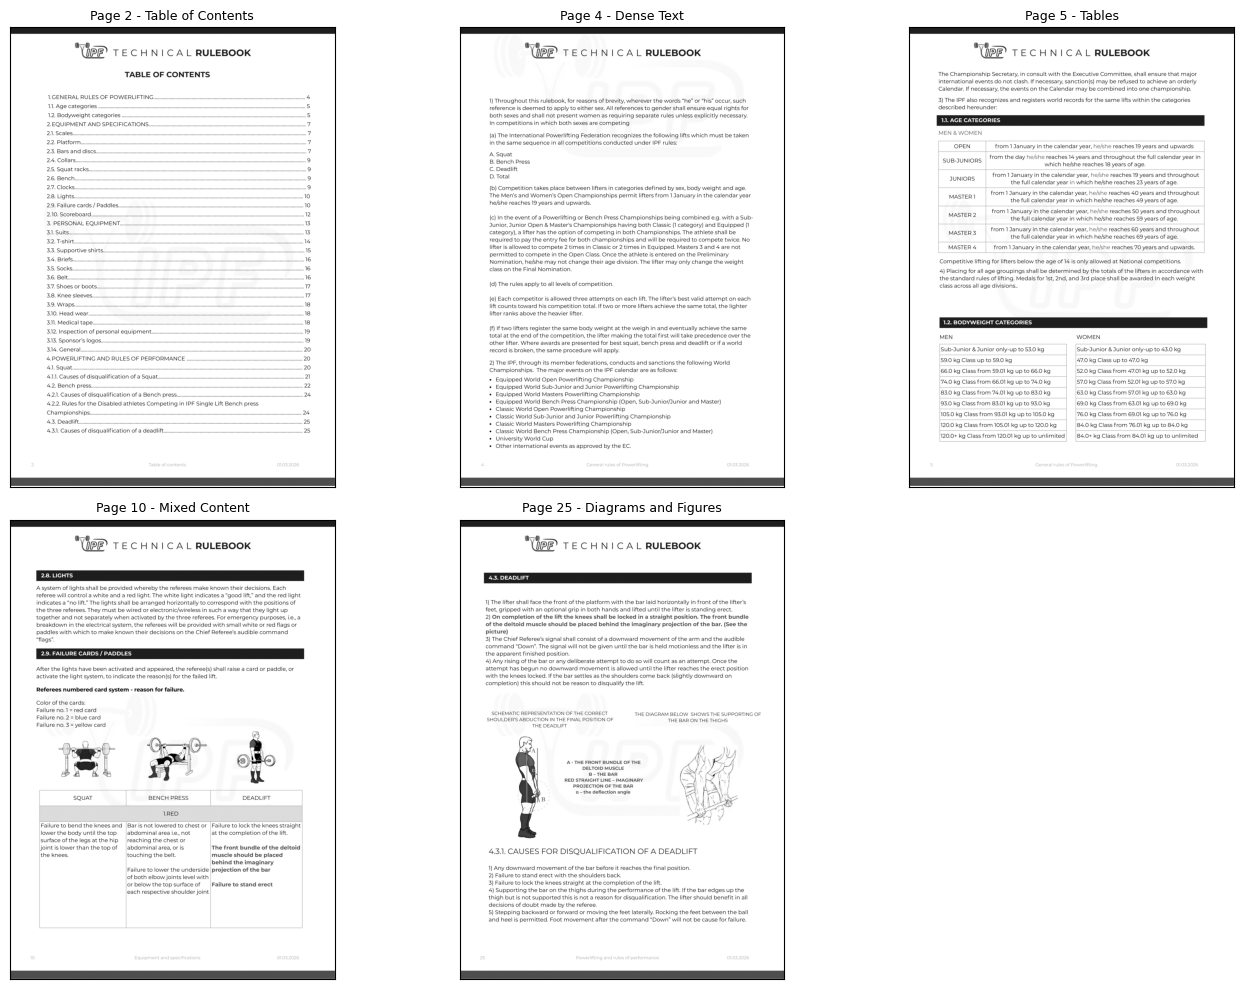

In [30]:
plt.figure(figsize=(14, 10))

for i in range(len(images)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i], fontsize=9)
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

## Use thresholding to remove the "IPF" watermark

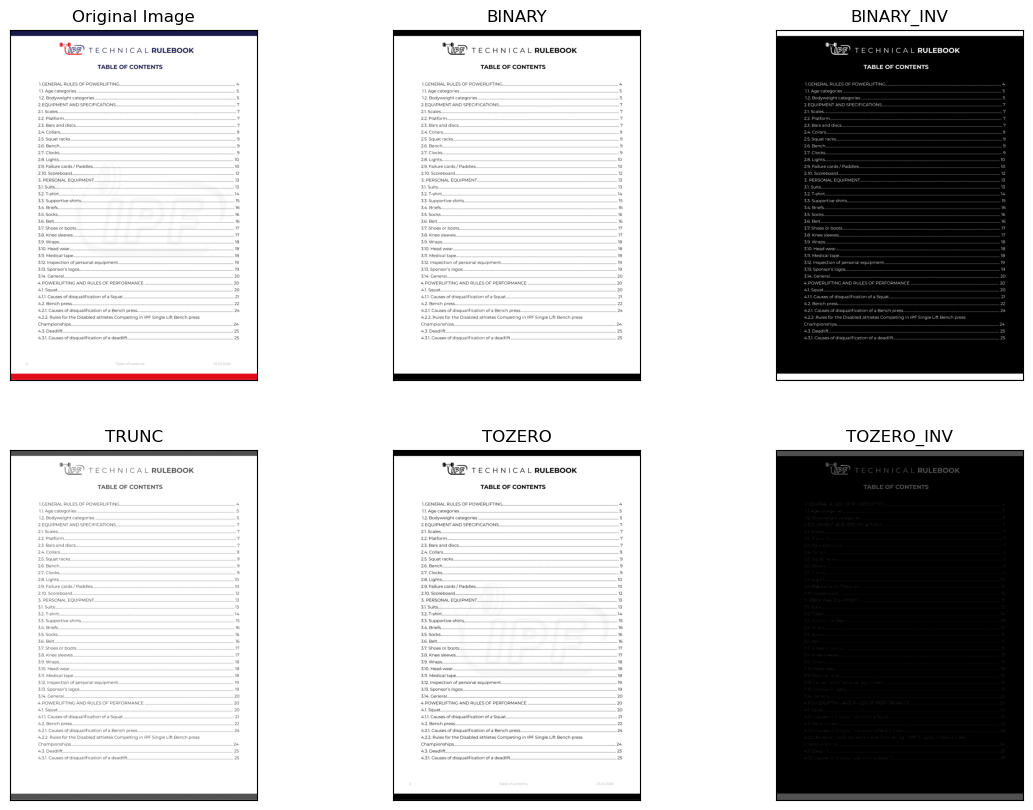

In [34]:
img = selected_pages[2]
img = np.array(img)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Thresholding is cool
ret,thresh1 = cv2.threshold(img_gray,127,255,cv2.THRESH_BINARY)
ret,thresh2 = cv2.threshold(img_gray,127,255,cv2.THRESH_BINARY_INV)
ret,thresh3 = cv2.threshold(img_gray,127,255,cv2.THRESH_TRUNC)
ret,thresh4 = cv2.threshold(img_gray,127,255,cv2.THRESH_TOZERO)
ret,thresh5 = cv2.threshold(img_gray,127,255,cv2.THRESH_TOZERO_INV)

titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

plt.figure(figsize=(14, 10))
for i in range(6):
    plt.subplot(2,3,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])


plt.show()


In [35]:
#binary thresholding option allows for watermark to be removed. 
#apply this to all pages and display for verification
binary_thresholded_pages = {}

for page_number in PAGE_NUMBERS:
    # Get page image from memory
    img = selected_pages[page_number]
    
    # Convert PIL image to NumPy array
    img = np.array(img)
    
    # Convert to grayscale
    img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    # Apply binary thresholding
    ret, thresh_binary = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)
    
    # Store result
    binary_thresholded_pages[page_number] = thresh_binary


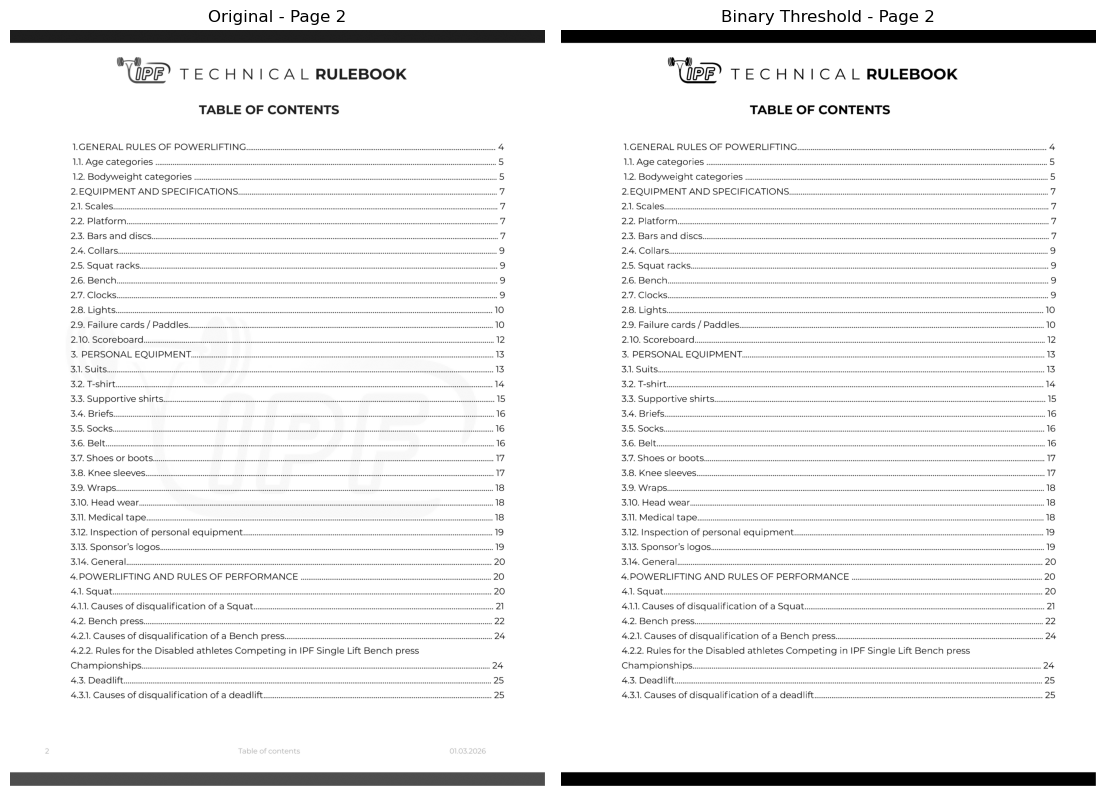

In [76]:
page_number = 2 

# Original
img = np.array(selected_pages[page_number])
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Thresholded
thresholded_img = binary_thresholded_pages[page_number]

plt.figure(figsize=(14, 10))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray")
plt.title(f"Original - Page {page_number}", fontsize=12)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(thresholded_img, cmap="gray")
plt.title(f"Binary Threshold - Page {page_number}", fontsize=12)
plt.axis("off")

plt.subplots_adjust(wspace=0.03)
plt.show()

preprocessed_pages = {}
preprocessed_pages[page_number] = thresholded_img


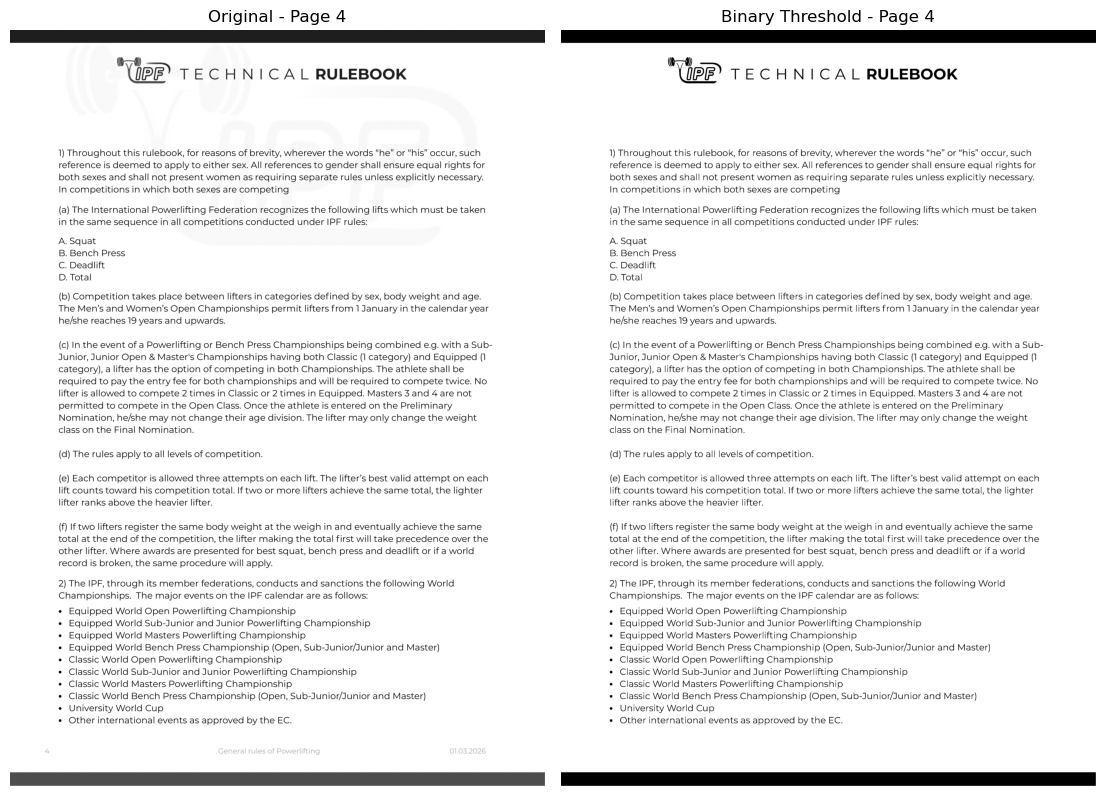

In [77]:
page_number = 4

# Original
img = np.array(selected_pages[page_number])
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Thresholded
thresholded_img = binary_thresholded_pages[page_number]

plt.figure(figsize=(14, 10))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray")
plt.title(f"Original - Page {page_number}", fontsize=12)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(thresholded_img, cmap="gray")
plt.title(f"Binary Threshold - Page {page_number}", fontsize=12)
plt.axis("off")

plt.subplots_adjust(wspace=0.03)
plt.show()

preprocessed_pages[page_number] = thresholded_img

After investigation fixed thresholding was unsuitable for tabular pages/diagram pages. Further experimentation was required.

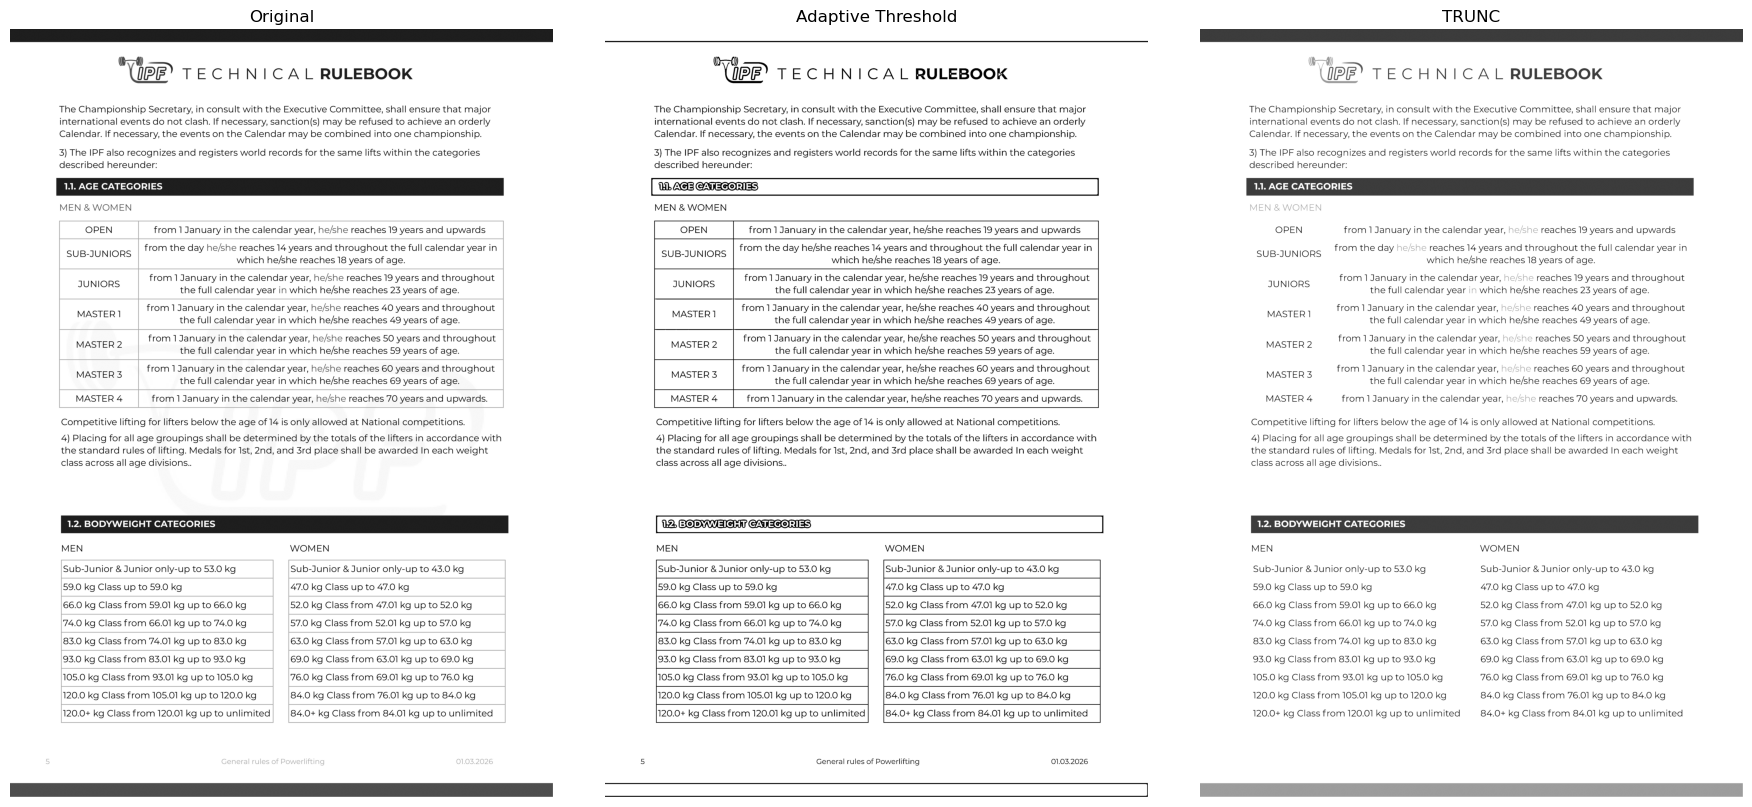

In [78]:
page_number = 5

# Original
img = np.array(selected_pages[page_number])
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Fixed binary threshold
ret, fixed_binary = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

# Adaptive threshold
adaptive_binary = cv2.adaptiveThreshold(
    img_gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    31,
    20
)

ret,thresh3 = cv2.threshold(img_gray,127,255,cv2.THRESH_TRUNC)

titles = ["Original", "Adaptive Threshold", "TRUNC"]
images = [img_gray, adaptive_binary, thresh3]

plt.figure(figsize=(18, 8))

for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i], fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.show()


preprocessed_pages[page_number] = adaptive_binary

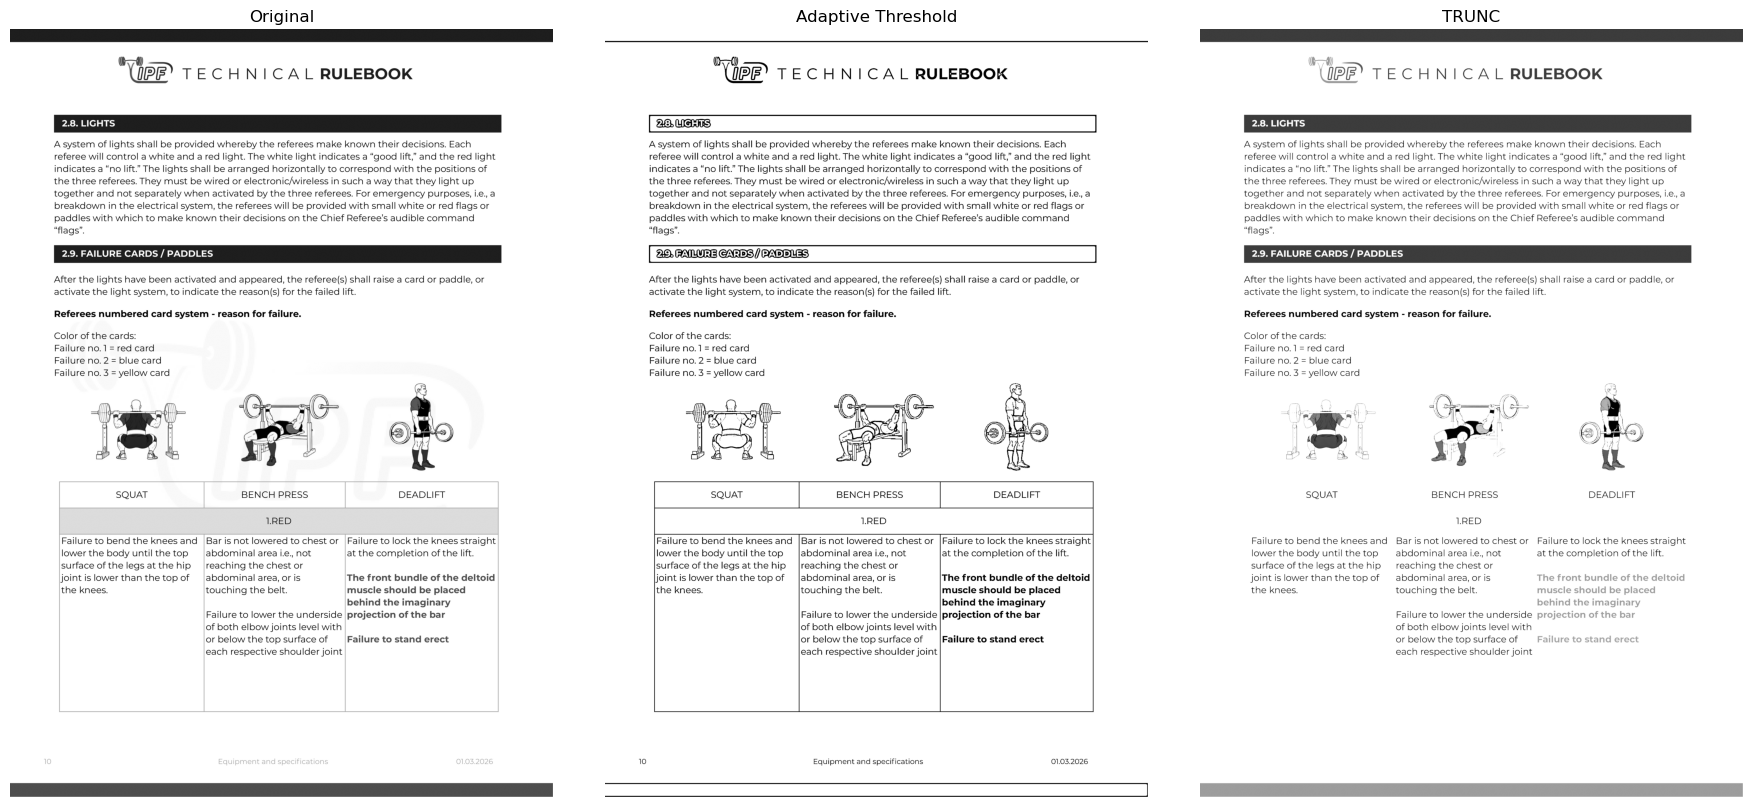

In [79]:
page_number = 10

# Original
img = np.array(selected_pages[page_number])
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Fixed binary threshold
ret, fixed_binary = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

# Adaptive threshold
adaptive_binary = cv2.adaptiveThreshold(
    img_gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    31,
    20
)

ret,thresh3 = cv2.threshold(img_gray,127,255,cv2.THRESH_TRUNC)

titles = ["Original", "Adaptive Threshold", "TRUNC"]
images = [img_gray, adaptive_binary, thresh3]

plt.figure(figsize=(18, 8))

for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i], fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.show()

preprocessed_pages[page_number] = adaptive_binary

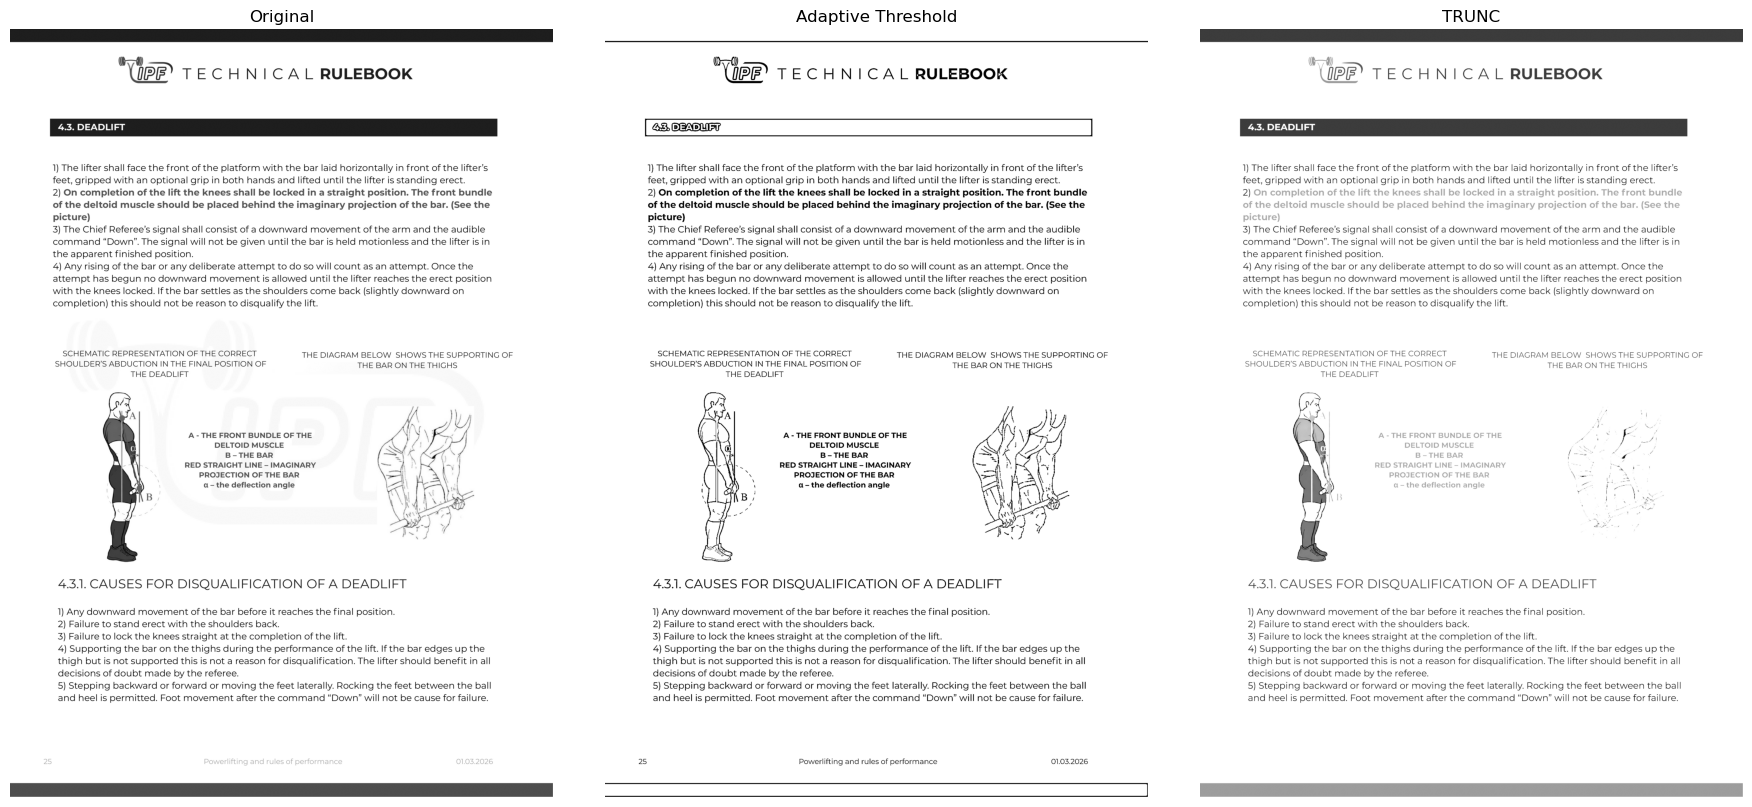

In [80]:
page_number = 25

# Original
img = np.array(selected_pages[page_number])
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Fixed binary threshold
ret, fixed_binary = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

# Adaptive threshold
adaptive_binary = cv2.adaptiveThreshold(
    img_gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    31,
    20
)

ret,thresh3 = cv2.threshold(img_gray,127,255,cv2.THRESH_TRUNC)

titles = ["Original", "Adaptive Threshold", "TRUNC"]
images = [img_gray, adaptive_binary, thresh3]

plt.figure(figsize=(18, 8))

for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i], fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.show()

preprocessed_pages[page_number] = adaptive_binary

A single preprocessing method did not work equally well for all page layouts. Fixed binary thresholding reduced the watermark on simpler text-heavy pages, but weakened table borders and structured content. Adaptive thresholding preserved the table, mixed-content, and diagram-based pages better, although it slightly altered the appearance of some dark section headings. Therefore, preprocessing was selected based on page content rather than applying one method blindly to every page

In [100]:
print(preprocessed_pages.keys())

dict_keys([2, 4, 5, 10, 25])


In [98]:
# ============================================================
# Section 2 - OCR Text Extraction
# Extracts text from the preprocessed page images using Tesseract
# ============================================================
ocr_results = {}

for page_number in PAGE_NUMBERS:
    print(f"Running OCR on Page {page_number} - {PAGE_LABELS[page_number]}...")

    # Get the preprocessed image from memory
    processed_img = preprocessed_pages[page_number]

    # Run OCR
    extracted_text = pytesseract.image_to_string(processed_img)

    # Store extracted text
    ocr_results[page_number] = extracted_text

print("\nOCR extraction complete.")

Running OCR on Page 2 - Table of Contents...
Running OCR on Page 4 - Dense Text...
Running OCR on Page 5 - Tables...
Running OCR on Page 10 - Mixed Content...
Running OCR on Page 25 - Diagrams and Figures...

OCR extraction complete.


In [102]:
for page_number in PAGE_NUMBERS:
    print("=" * 80)
    print(f"Page {page_number} - {PAGE_LABELS[page_number]}")
    print("=" * 80)
    print(ocr_results[page_number])
    print("\n")

Page 2 - Table of Contents
&
LI

T | J D

a

— —




Page 4 - Dense Text
(+?) =)
IPF’ TECHNICAL RULEBOOK

1) Throughout this rulebook, for reasons of brevity, wherever the words “he” or “his” occur, such
reference is deemed to apply to either sex. All references to gender shall ensure equal rights for
both sexes and shall not present women as requiring separate rules unless explicitly necessary.
In competitions in which both sexes are competing

(a) The International Powerlifting Federation recognizes the following lifts which must be taken
in the same sequence in all competitions conducted under IPF rules:

A. Squat

B. Bench Press
C. Deadlift

D. Total

(6b) Competition takes place between lifters in categories defined by sex, body weight and age.
The Men’s and Women’s Open Championships permit lifters from 1 January in the calendar year
he/she reaches 19 years and upwards.

(c) In the event of a Powerlifting or Bench Press Championships being combined e.g. with a Sub-
Junior, Junior

In [104]:
page_number = 2

img = np.array(selected_pages[page_number])
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

toc_text = pytesseract.image_to_string(
    img_gray,
    config="--psm 6"
)

print(toc_text)

toc_text_sparse = pytesseract.image_to_string(
    img_gray,
    config="--psm 11"
)

print(toc_text_sparse)

nO ——————————E—E—eeererererer
"UIPE) TECHNICAL RULEBOOK
TABLE OF CONTENTS

TT. AGG CATS QOLIES ooeececccccsccssessessessessssussessessecssssssessessesussussusssssessessssussscssssesssssssscssssscsssussussscsssuecsssussscsesseasseussessesacansescsuesessessesssteseesceseasee OD
T.2. BODYWEIGNt CATEGOLIES ooeeeecccccccssessessessessessesessessesssssssssssseesssssscsssssesecsssuesssssssecsssussucasssesecssaucassaseseesssneascsesseessaseatsatesteseeseacessesee
Qe]. SCALSS.eccecessessssssessecsessesssssnecsscsecscsusssssucsuscuccsscsscsucsussussussuessecssssucsussuccscssecsscsusssssucsuccscesscsucsecsucsuscucssessesseeseesucsuecsessecsessesessscsaeesessseseesseneee 7
2.2. PLACFOPM ...cccsecssessssssesssesssessscssessscssessuscuscsusssssssscsucsuscsusssssesscsucsusssscessceuccusssuecsscesscsscsuscsuccssseuccasssucssuccseceuccsscsuesseccsecesccsesssecseecsecscsseessecseeese Z
2.3. BALS AN? CISCS.o.cecsecssessessessesssessesnecsessesssssucssssuccasssessscsussuccscssecusssscsussucsucsuccscsusses

# Vision

## Sub Heading 1

In [6]:
# code here...

# Multi-modal

## Sub Heading 1

In [7]:
# code here

# Final Output

In [8]:
# code